In [27]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.feature_engineering import FEATURE_COLUMNS, TARGET_COLUMN

In [28]:
import pandas as pd
from src.feature_engineering import FEATURE_COLUMNS, TARGET_COLUMN

df = pd.read_csv("../data/processed/features.csv", parse_dates=["date"])

print(df.columns.tolist())
print(df[FEATURE_COLUMNS + [TARGET_COLUMN]].isnull().sum())

['date', 'region_id', 'region_intensity', 'urbanization_index', 'rainfall_mm', 'soil_saturation_pct', 'reservoir_level_pct', 'flash_flood', 'month', 'day_of_year', 'is_monsoon', 'rainfall_3d_sum', 'rainfall_7d_sum', 'rainfall_change_1day', 'soil_saturation_change_3day', 'reservoir_change_3day', 'rain_saturation_interaction', 'days_since_significant_rain']
rainfall_mm                    0
soil_saturation_pct            0
reservoir_level_pct            0
rainfall_3d_sum                0
rainfall_7d_sum                0
rainfall_change_1day           0
soil_saturation_change_3day    0
reservoir_change_3day          0
rain_saturation_interaction    0
days_since_significant_rain    0
month                          0
is_monsoon                     0
urbanization_index             0
flash_flood                    0
dtype: int64


In [25]:
import pandas as pd

df = pd.read_csv("../data/raw/synthetic_flashflood_data.csv")

heavy_rain_dry_ground = df[
    (df["rainfall_mm"] >= 30) &
    (df["soil_saturation_pct"] < 40)
]

print(f"Heavy rain on dry ground: {len(heavy_rain_dry_ground)} days")
print(f"Of those, flooded: {heavy_rain_dry_ground['flash_flood'].sum()}")

print(df[["region_intensity", "flash_flood"]].corr())
print(df[["urbanization_index", "flash_flood"]].corr())

Heavy rain on dry ground: 32 days
Of those, flooded: 0
                  region_intensity  flash_flood
region_intensity          1.000000     0.035806
flash_flood               0.035806     1.000000
                    urbanization_index  flash_flood
urbanization_index            1.000000     0.013119
flash_flood                   0.013119     1.000000


In [23]:
import pandas as pd

df = pd.read_csv("../data/processed/features.csv", parse_dates=["date"])

df.head(10)

df.isnull().sum()  # should be all zero

date                           0
region_id                      0
region_intensity               0
urbanization_index             0
rainfall_mm                    0
soil_saturation_pct            0
reservoir_level_pct            0
flash_flood                    0
month                          0
day_of_year                    0
is_monsoon                     0
rainfall_3d_sum                0
rainfall_7d_sum                0
rainfall_3day_sum              0
rainfall_7day_sum              0
rainfall_change_1day           0
soil_saturation_change_3day    0
reservoir_change_3day          0
rain_saturation_interaction    0
days_since_significant_rain    0
dtype: int64

In [18]:
from pathlib import Path

print(Path.cwd())
print(list(Path("../data/processed").glob("*")))

c:\Users\Uhgj\project\Flash-flood\ml\flashflood-layer1\notebooks
[WindowsPath('../data/processed/features.csv')]


In [19]:
df = pd.read_csv("../data/processed/features.csv", parse_dates=["date"])

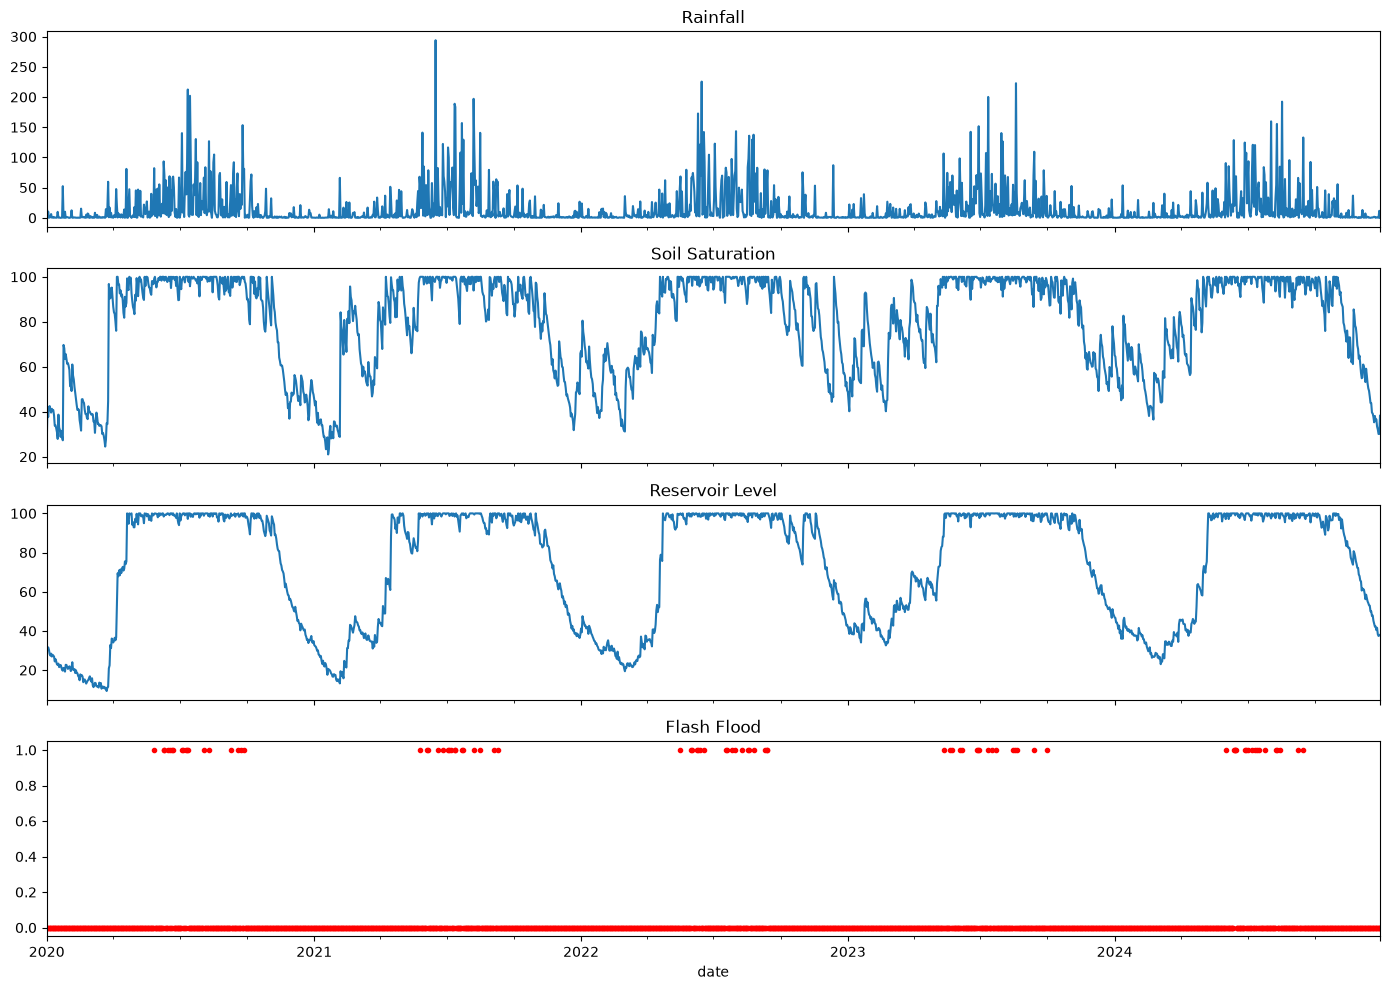

In [13]:
one_region = df[df["region_id"] == "region_1"].set_index("date")
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
one_region["rainfall_mm"].plot(ax=axes[0], title="Rainfall")
one_region["soil_saturation_pct"].plot(ax=axes[1], title="Soil Saturation")
one_region["reservoir_level_pct"].plot(ax=axes[2], title="Reservoir Level")
one_region["flash_flood"].plot(ax=axes[3], title="Flash Flood", style="r.")
plt.tight_layout()
plt.show()

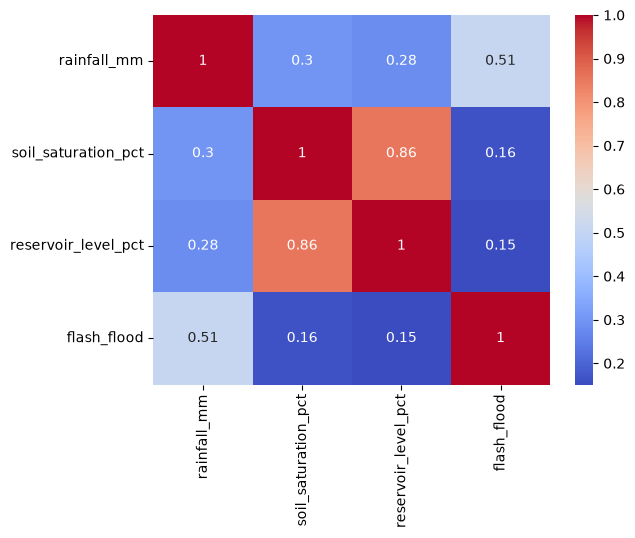

In [12]:
sns.heatmap(df[features + ["flash_flood"]].corr(), annot=True, cmap="coolwarm")
plt.show()

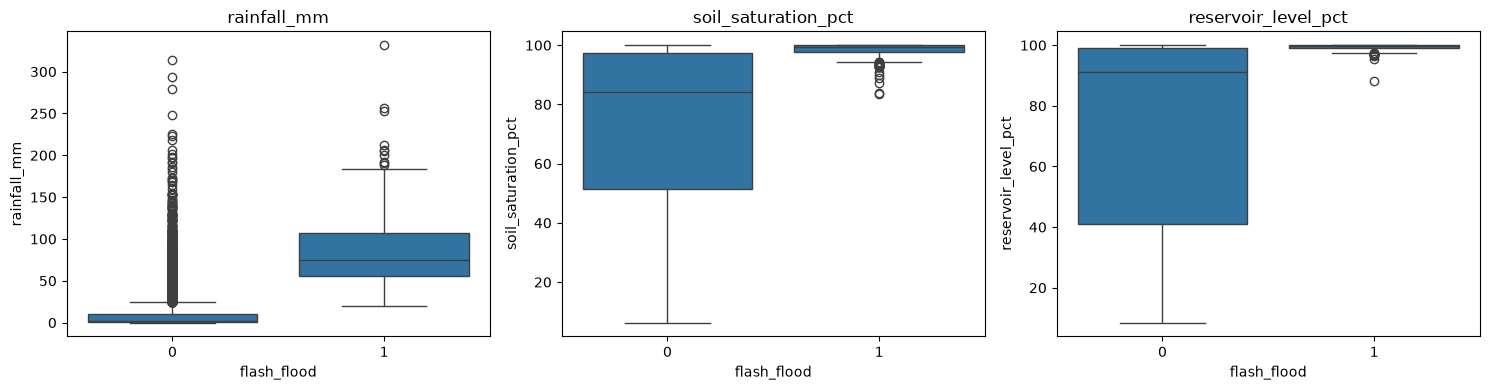

In [11]:
features = ["rainfall_mm", "soil_saturation_pct", "reservoir_level_pct"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, features):
    sns.boxplot(x="flash_flood", y=feat, data=df, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

flash_flood
0    0.969954
1    0.030046
Name: proportion, dtype: float64


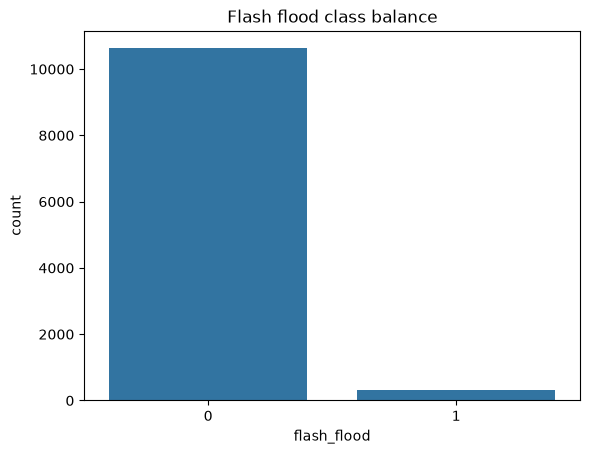

In [10]:
print(df["flash_flood"].value_counts(normalize=True))
sns.countplot(x="flash_flood", data=df)
plt.title("Flash flood class balance")
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/synthetic_flashflood_data.csv", parse_dates=["date"])
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()

(10950, 13)
date                   datetime64[ns]
region_id                      object
region_intensity              float64
urbanization_index            float64
rainfall_mm                   float64
soil_saturation_pct           float64
reservoir_level_pct           float64
flash_flood                     int64
month                           int64
day_of_year                     int64
is_monsoon                      int64
rainfall_3d_sum               float64
rainfall_7d_sum               float64
dtype: object
date                   0
region_id              0
region_intensity       0
urbanization_index     0
rainfall_mm            0
soil_saturation_pct    0
reservoir_level_pct    0
flash_flood            0
month                  0
day_of_year            0
is_monsoon             0
rainfall_3d_sum        0
rainfall_7d_sum        0
dtype: int64


,date,region_intensity,urbanization_index,rainfall_mm,soil_saturation_pct,reservoir_level_pct,flash_flood,month,day_of_year,is_monsoon,rainfall_3d_sum,rainfall_7d_sum
count,10950,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000,10950.000000
mean,2022-07-01 00:00:00,1.057833,0.473167,12.869653,74.390018,72.657963,0.030046,6.515068,183.000548,0.358904,38.604795,90.064840
min,2020-01-01 00:00:00,0.832000,0.154000,0.000000,6.300000,8.500000,0.000000,1.000000,1.000000,0.000000,0.000000,0.100000
25%,2021-04-01 00:00:00,0.869000,0.219000,0.600000,52.200000,42.300000,0.000000,4.000000,92.000000,0.000000,4.000000,18.700000
50%,2022-07-01 00:00:00,0.961500,0.491000,2.200000,85.700000,92.850000,0.000000,7.000000,183.000000,0.000000,17.300000,53.200000
75%,2023-09-30 00:00:00,1.319000,0.591000,11.900000,97.700000,99.300000,0.000000,10.000000,274.000000,1.000000,52.900000,129.700000
max,2024-12-29 00:00:00,1.404000,0.893000,331.600000,100.000000,100.000000,1.000000,12.000000,366.000000,1.000000,668.600000,773.700000
std,NaN,0.221173,0.245862,25.673232,26.035219,31.148123,0.170721,3.446484,105.371789,0.479701,52.358903,98.572884


In [8]:
%pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import sys
print(sys.executable)

c:\Users\Uhgj\AppData\Local\Python\pythoncore-3.12-64\python.exe
